Import libraries

In [1]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt

import collections

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.optimizers import Adam

import pathlib

from sklearn.metrics import classification_report, confusion_matrix




Autotune Data

In [2]:
autotune = tf.data.AUTOTUNE
batch_size = 32
img_size = (150, 150)
class_names = ['normal', 'pneumonia', 'tuberculosis']
buffer_size = 10000

In [3]:
data_root = pathlib.Path( r"/Users/michaelperrine/Library/CloudStorage/OneDrive-Personal/Documents/Bellevue/Applied Data Science/Project 3/archive")

In [4]:
train_dir = data_root/'train'
val_dir = data_root/'val'
test_dir = data_root/'test'

In [5]:
train_ds =tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size = img_size,
    color_mode = 'grayscale',
    batch_size = batch_size,
    shuffle = True
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size = img_size,
    color_mode = 'grayscale',
    batch_size = batch_size,
    shuffle =False
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size = img_size,
    color_mode = 'grayscale',
    batch_size = batch_size,
    shuffle = False
)

print('Inferred Class Names:', class_names)
num_classes = len(class_names)

Found 20450 files belonging to 3 classes.
Found 2534 files belonging to 3 classes.
Found 2569 files belonging to 3 classes.
Inferred Class Names: ['normal', 'pneumonia', 'tuberculosis']


2025-11-16 17:07:27.104273: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2025-11-16 17:07:27.104309: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2025-11-16 17:07:27.104313: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
2025-11-16 17:07:27.104480: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-11-16 17:07:27.104490: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [6]:
train_ds = train_ds.cache().shuffle(buffer_size).prefetch(buffer_size = autotune)
val_ds = val_ds.cache().prefetch(buffer_size = autotune)
test_ds = test_ds.cache().prefetch(buffer_size = autotune)


Calculate class weights to handle class imbalance

In [7]:


class_counts = collections.Counter()

for _, labels in train_ds:
    class_counts.update(labels.numpy().tolist())
print('Class Counts:', class_counts)

normal_iamage_count = class_counts[0]
pneumonia_image_count = class_counts[1]
tuberculosis_image_count = class_counts[2]
total_image_count = sum(class_counts.values())

weight_for_normal = total_image_count / (3 * normal_iamage_count)
weight_for_pneumonia = total_image_count / (3 * pneumonia_image_count)
weight_for_tuberculosis = total_image_count / (3 * tuberculosis_image_count)
class_weight = {
    0: weight_for_normal, 
    1: weight_for_pneumonia, 
    2: weight_for_tuberculosis}

print('Class Weights:' , class_weight)

    

Class Counts: Counter({2: 8513, 0: 7263, 1: 4674})
Class Weights: {0: 0.9385469732433797, 1: 1.4584224789616318, 2: 0.8007361290575199}


2025-11-16 17:07:34.557887: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Visualize Data

2025-11-16 17:07:34.639678: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


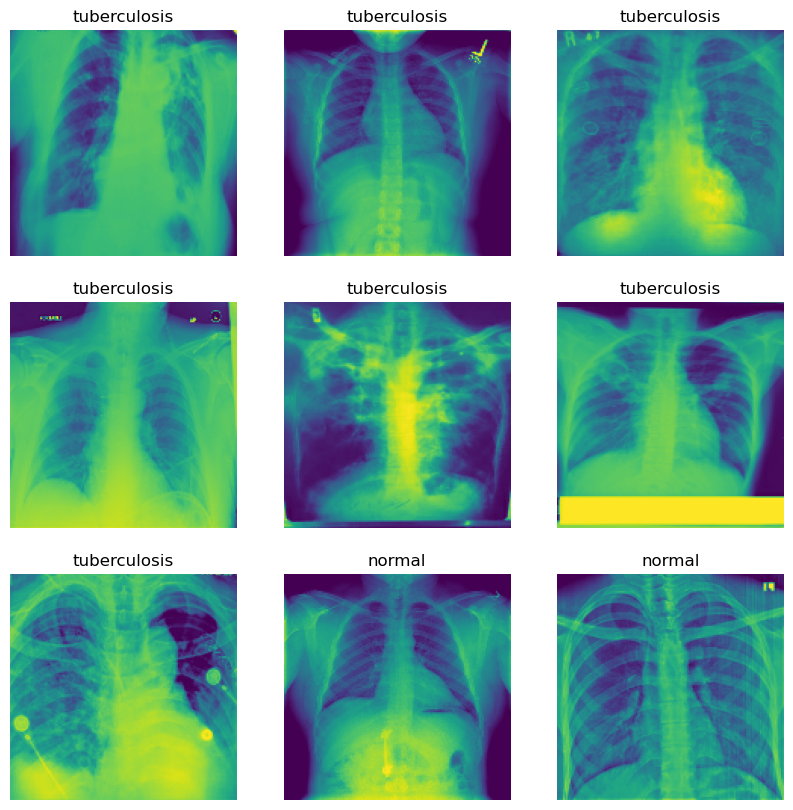

In [8]:
plt.figure(figsize=(10,10))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(np.squeeze(images[i].numpy().astype('uint8')))
        plt.title(class_names[labels[i]])
        plt.axis('off')

Build CNN

In [9]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
])

inputs = tf.keras.Input(shape = img_size + (1,))
x = data_augmentation(inputs)
x = tf.keras.layers.Rescaling(1./255)(x)

x = tf.keras.layers.Conv2D(32, (3, 3), activation = 'relu', padding = 'same')(x)
x = tf.keras.layers.MaxPooling2D()(x)

x = tf.keras.layers.Conv2D(64, (3, 3), activation = 'relu', padding = 'same')(x)
x = tf.keras.layers.MaxPooling2D()(x)

x = tf.keras.layers.Conv2D(128, (3, 3), activation = 'relu', padding = 'same')(x)
x = tf.keras.layers.MaxPooling2D()(x)

x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.5)(x)
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(128, activation = 'relu')(x)

outputs = tf.keras.layers.Dense(num_classes, activation = 'softmax')(x)

model = tf.keras.Model(inputs = inputs, outputs = outputs)


In [10]:
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 150, 150, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 150, 150, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,571 (428.01 KB)

 Trainable params: 109,571 (428.01 KB)

 Non-trainable params: 0 (0.00 B)

Train Model

In [11]:
history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 20,
    class_weight = class_weight
)

Epoch 1/20


2025-11-16 17:07:35.205352: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


640/640 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.5389 - loss: 0.8636 - val_accuracy: 0.6085 - val_loss: 0.7686
Epoch 2/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.5967 - loss: 0.7608 - val_accuracy: 0.5919 - val_loss: 0.8015
Epoch 3/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.5690 - loss: 0.8418 - val_accuracy: 0.6085 - val_loss: 0.8711
Epoch 4/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.5233 - loss: 1.1399 - val_accuracy: 0.4850 - val_loss: 1.3967
Epoch 5/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.4954 - loss: 2.0340 - val_accuracy: 0.4811 - val_loss: 2.9986
Epoch 6/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.4749 - loss: 4.6726 - val_accuracy: 0.4874 - val_loss: 4.6154
Epoch 7/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.4633 - loss: 11.8668 - val_accuracy: 0.4964 - val_loss: 9.1488
Epoch 8/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.4618 - loss: 14.8692 - val_accur

Evaluate

In [12]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Accuracy: {test_accuracy:.4f}")

81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5679 - loss: 191.1827
Test Accuracy: 0.5679


In [13]:
model.save('xray classification_model1.keras')

Build Second Model to test improvements in model

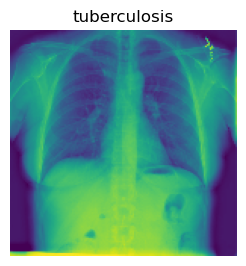

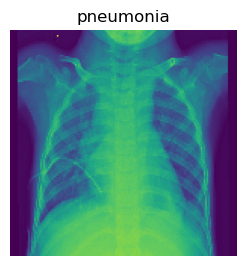

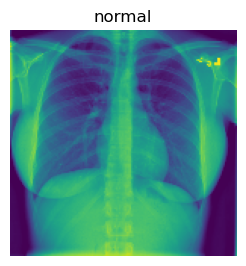

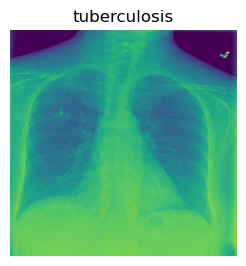

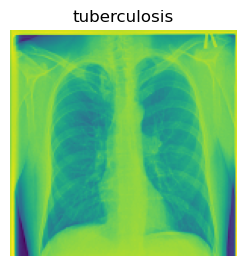

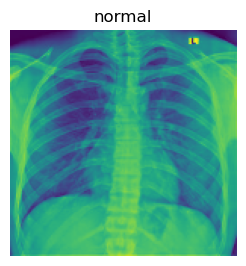

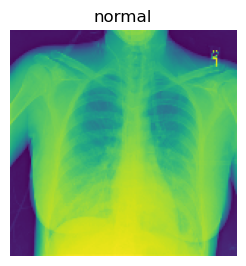

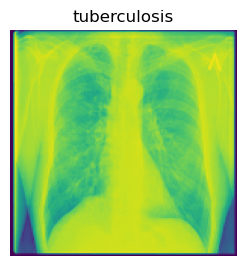

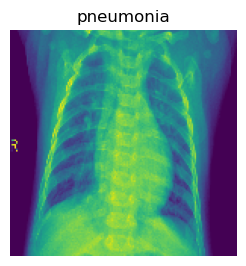

2025-11-16 17:13:37.170724: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [14]:

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.figure(figsize=(10, 10))         
        plt.subplot(3, 3 , i + 1)
        plt.imshow(np.squeeze(images[i].numpy().astype('uint8')))
        plt.title(class_names[labels[i]])
        plt.axis('off')
        plt.show()

Reload data with new size

In [15]:
img_size2 = (224, 224)
batch_size2 = 32
num_classes2 = len(class_names)

train_ds2 = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size = img_size2,
    color_mode = 'grayscale',
    batch_size = batch_size2,
    shuffle = True
)

val_ds2 = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size = img_size2,
    color_mode = 'grayscale',
    batch_size = batch_size2,
    shuffle = False
)

test_ds2 = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size = img_size2,
    color_mode = 'grayscale',
    batch_size = batch_size2,
    shuffle = False
)
print('Inferred Class Names:', class_names)

Found 20450 files belonging to 3 classes.
Found 2534 files belonging to 3 classes.
Found 2569 files belonging to 3 classes.
Inferred Class Names: ['normal', 'pneumonia', 'tuberculosis']


In [16]:
Autotune = tf.data.AUTOTUNE
train_ds2 = train_ds2.cache().shuffle(buffer_size).prefetch(buffer_size = Autotune)
val_ds2 = val_ds2.cache().prefetch(buffer_size = Autotune)
test_ds2 = test_ds2.cache().prefetch(buffer_size = Autotune)

data_augmentation2 = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1)
])


Pretrained backbone

In [17]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top = False,
    input_shape = img_size2 + (3,),
    weights = 'imagenet'
)
# Freeze the base model
base_model.trainable = False
# Reload data with new size
inputs2 = tf.keras.Input(shape = img_size2 + (1,))
x2 = data_augmentation2(inputs2)
# Rescale grayscale to 3 channels
x2 = tf.keras.layers.Rescaling(1./255)(x2)
# Convert grayscale to RGB by repeating channels
x2 = tf.keras.layers.Concatenate()([x2, x2, x2])

x2 =  base_model(x2, training =False)
x2 = tf.keras.layers.GlobalAveragePooling2D()(x2)
x2 = tf.keras.layers.Dropout(0.4)(x2)
x2 = tf.keras.layers.Flatten()(x2)
outputs2 = tf.keras.layers.Dense(num_classes2, activation = 'softmax')(x2)

Build Model

In [18]:
model2 = tf.keras.Model(inputs2, outputs2)
model2.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 1e-3),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [19]:
base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

# Continue with training model2
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 1e-4),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

Tune training setup

In [20]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor = 'val_loss',
        patience = 5,
        restore_best_weights = True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor = 'val_loss',
        factor = 0.5,
        patience = 2,
        min_lr = 1e-6
    )
]

history2 = model2.fit(
    train_ds2,
    validation_data = val_ds2,
    epochs = 30,
    class_weight = class_weight,
    callbacks = callbacks
)

Epoch 1/30
640/640 ━━━━━━━━━━━━━━━━━━━━ 186s 255ms/step - accuracy: 0.6081 - loss: 0.7293 - val_accuracy: 0.4183 - val_loss: 1.6290 - learning_rate: 0.0010
Epoch 2/30
640/640 ━━━━━━━━━━━━━━━━━━━━ 158s 247ms/step - accuracy: 0.6706 - loss: 0.6057 - val_accuracy: 0.6456 - val_loss: 0.7125 - learning_rate: 0.0010
Epoch 3/30
640/640 ━━━━━━━━━━━━━━━━━━━━ 156s 244ms/step - accuracy: 0.7058 - loss: 0.5442 - val_accuracy: 0.6709 - val_loss: 0.6566 - learning_rate: 0.0010
Epoch 4/30
640/640 ━━━━━━━━━━━━━━━━━━━━ 157s 245ms/step - accuracy: 0.7169 - loss: 0.5072 - val_accuracy: 0.6125 - val_loss: 0.7628 - learning_rate: 0.0010
Epoch 5/30
640/640 ━━━━━━━━━━━━━━━━━━━━ 157s 245ms/step - accuracy: 0.7277 - loss: 0.4854 - val_accuracy: 0.7103 - val_loss: 0.5457 - learning_rate: 0.0010
Epoch 6/30
640/640 ━━━━━━━━━━━━━━━━━━━━ 158s 247ms/step - accuracy: 0.7377 - loss: 0.4706 - val_accuracy: 0.6953 - val_loss: 0.5215 - learning_rate: 0.0010
Epoch 7/30
640/640 ━━━━━━━━━━━━━━━━━━━━ 157s 245ms/step - accura

In [22]:
test_loss, test_accuracy = model2.evaluate(test_ds2)
print(f"Test Accuracy : {test_accuracy: .4f}")

81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - accuracy: 0.7657 - loss: 0.4279
Test Accuracy :  0.7657


In [23]:
model2.save('xray_2.keras')